In [66]:
ONE.setup(base_url='https://openalyx.internationalbrainlab.org', silent=True)
one = ONE(password='international')

Connected to https://openalyx.internationalbrainlab.org as user "intbrainlab"


In [70]:
# Suppress some future warnings
import warnings
warnings.simplefilter("ignore", FutureWarning)

# Change the load method depending on python version
from one.remote.aws import s3_download_file, get_s3_public
import pandas as pd
import sys
python_ver = sys.version_info

if python_ver >= (3, 10):
    from one.alf.path import add_uuid_string
else:
    from one.alf.files import add_uuid_string

s3, bucket = get_s3_public()

def load_aggregate(subject, dataset):
    if sys.version_info >= (3, 10):
        return one.load_aggregate('subjects', subject, dataset)
    else:
        files = one.list_aggregates('subjects', subject, dataset=dataset)
        files = files.iloc[0]
        src_path = str(add_uuid_string(files['rel_path'], files.name))
        dst_path = one.cache_dir.joinpath(files['rel_path'])
        local_file = s3_download_file(src_path, dst_path, s3=s3, bucket_name=bucket)
        return pd.read_parquet(local_file)

In [72]:
# Find all aggregate training datasets from IBL behaviour paper
datasets = one.alyx.rest('datasets', 'list', tag='2021_Q1_IBL_et_al_Behaviour', name='_ibl_subjectTraining.table.pqt')

# Find the subject name from the info stored in the relative path
subjects = np.unique([d['file_records'][0]['relative_path'].split('/')[2] for d in datasets])

In [81]:
# Load training status for subject
subject_training = load_aggregate(subjects[0], '_ibl_subjectTraining.table.pqt')


In [ ]:
# check the unique values of the training_status column
subject_training.training_status.unique()

array(['in training', 'untrainable', 'trained 1b', 'ready4ephysrig',
       'ready4delay', 'ready4recording'], dtype=object)

In [ ]:
# Download two tables, subject trials table and subject training table and combine
 
all_trials = []

for i, subject in enumerate(subjects):
  if np.mod(i, 50) == 0:
    print(f'{i}/{len(subjects)}')

  # Load trials table for subject
  subject_trials = load_aggregate(subject, '_ibl_subjectTrials.table.pqt')

  # Load sessions table for subject
  session_trials = load_aggregate(subject, '_ibl_subjectSessions.table.pqt')

  # Load training status for subject
  subject_training = load_aggregate(subject, '_ibl_subjectTraining.table.pqt')

  # Combine the two tables
  subject_trials = (subject_trials
            .set_index('session')
            .join(subject_training.set_index('session'))
            .sort_values(by=['session_start_time', 'intervals_0']))
  #subject_trials['training_status'] = subject_trials.training_status.fillna(method='ffill')

  # Join sessions table for number, task_protocol, etc.
  if 'task_protocol' in subject_trials:
      subject_trials = subject_trials.drop('task_protocol', axis=1)
  subject_trials = subject_trials.join(session_trials.drop('date', axis=1))

  # Sort the trials by session start time and trial number
  subject_trials = subject_trials.sort_values(by=['session_start_time', 'intervals_0'])


  # add in extra column for training day
  sessions = subject_trials.index.unique()
  for n_sess, sess in enumerate(sessions):
    trials = subject_trials[subject_trials.index == sess]
    subject_trials.loc[subject_trials.index == sess, 'training_day'] = n_sess


  all_trials.append(subject_trials)

all_trials = pd.concat(all_trials)

0/140


(S3) C:\Users\Lak Lab\Downloads\ONE\openalyx.internationalbrainlab.org\aggregates\Subjects\churchlandlab\CSHL_007\_ibl_subjectSessions.table.pqt: 100%|██████████| 9.12k/9.12k [00:00<00:00, 39.1kB/s]
(S3) C:\Users\Lak Lab\Downloads\ONE\openalyx.internationalbrainlab.org\aggregates\Subjects\churchlandlab\CSHL_007\#2024-08-21#\_ibl_subjectTraining.table.pqt: 100%|██████████| 3.25k/3.25k [00:00<00:00, 17.1kB/s]
(S3) C:\Users\Lak Lab\Downloads\ONE\openalyx.internationalbrainlab.org\aggregates\Subjects\churchlandlab\CSHL_008\#2024-08-21#\_ibl_subjectTrials.table.pqt: 100%|██████████| 4.96M/4.96M [00:01<00:00, 4.02MB/s]
(S3) C:\Users\Lak Lab\Downloads\ONE\openalyx.internationalbrainlab.org\aggregates\Subjects\churchlandlab\CSHL_008\_ibl_subjectSessions.table.pqt: 100%|██████████| 8.82k/8.82k [00:00<00:00, 43.6kB/s]
(S3) C:\Users\Lak Lab\Downloads\ONE\openalyx.internationalbrainlab.org\aggregates\Subjects\churchlandlab\CSHL_008\_ibl_subjectTraining.table.pqt: 100%|██████████| 3.14k/3.14k [00:0

<Axes: xlabel='signed_contrast', ylabel='choice'>

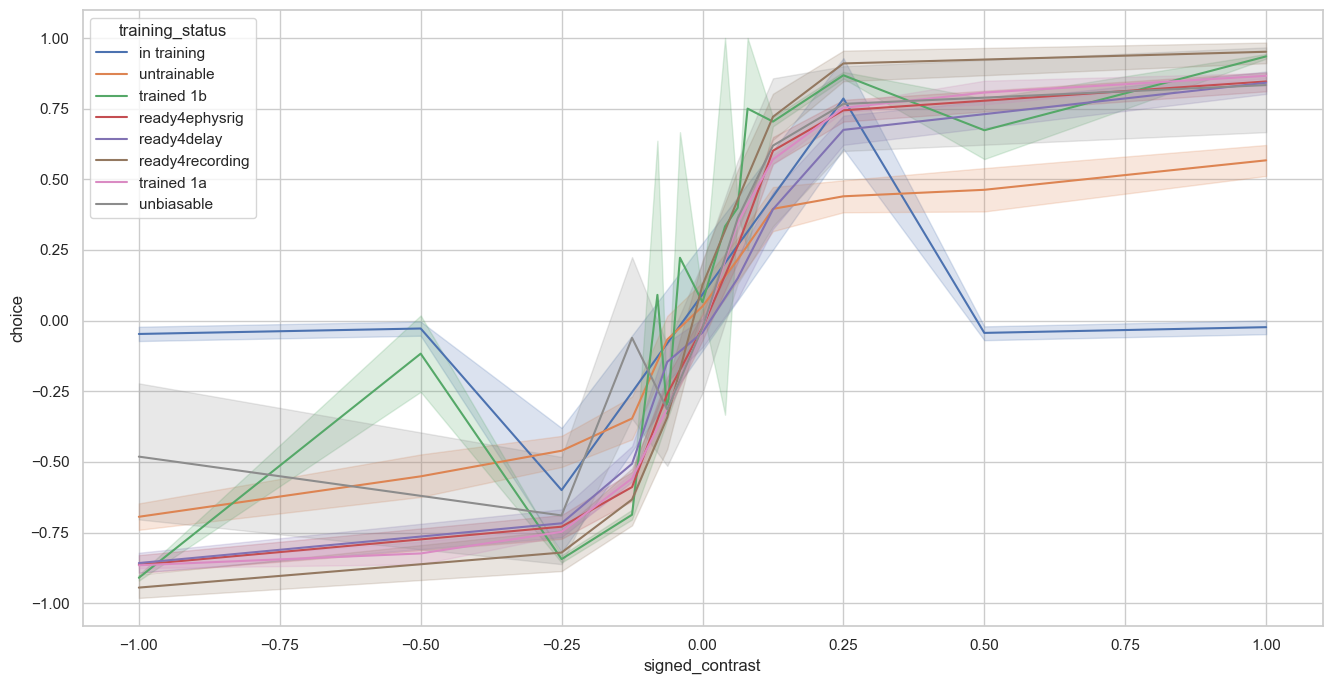

In [ ]:
# plot psychometric curves for the whole dataframe
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

all_trials = all_trials.reset_index()
all_trials['signed_contrast'] = np.nan
i = np.isnan(all_trials['contrastRight'])
all_trials.loc[i , 'signed_contrast'] = all_trials.loc[i, 'contrastLeft']
all_trials.loc[~i, 'signed_contrast'] = - all_trials.loc[~i, 'contrastRight']

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(16, 8))
sns.lineplot(data=all_trials.loc[all_trials['probabilityLeft'] == 0.5], x='signed_contrast', y='choice', hue='training_status', ax=ax)

In [ ]:
# Filter sessions with training_status 'unbiasable'
unbiasable_sessions = all_trials[all_trials['training_status'] == 'unbiasable']

# See how many unique sessions there are with this status
unique_unbiasable_sessions = unbiasable_sessions['session'].unique()
print(f"Number of unique sessions with training_status 'unbiasable': {len(unique_unbiasable_sessions)}")

# See the unique sessions
print("\nSessions with training_status 'unbiasable':")
for session in unique_unbiasable_sessions:
    print(f"  {session}")

# See detailed information of these sessions
print(f"\nDetailed information of 'unbiasable' sessions:")
print(unbiasable_sessions[['session', 'training_status', 'training_day', 'session_start_time']].drop_duplicates())

# See how many trials there are in total for these sessions
print(f"\nTotal trials in 'unbiasable' sessions: {len(unbiasable_sessions)}")

# See the distribution by subject
print(f"\nDistribution by subject:")
subject_counts = unbiasable_sessions.groupby('subject').size()
print(subject_counts)

Número de sesiones únicas con training_status 'unbiasable': 6

Sesiones con training_status 'unbiasable':
  f282c9f2-c2dd-462c-8511-bb2944294556
  1771537f-600d-4031-a0a2-46da55d90114
  06dda5a6-d286-4d45-939b-fc909ae2b1b7
  4a84dea1-ea21-427b-b46c-a4f62e8de0f9
  a362b866-4059-4cef-9887-9f806f26ec3b
  24ce6c2c-0fc8-4133-8fe5-8d73974349a3

Información detallada de las sesiones 'unbiasable':
                                      session training_status  training_day  \
657941   f282c9f2-c2dd-462c-8511-bb2944294556      unbiasable          68.0   
887494   1771537f-600d-4031-a0a2-46da55d90114      unbiasable          49.0   
1739486  06dda5a6-d286-4d45-939b-fc909ae2b1b7      unbiasable          65.0   
2357258  4a84dea1-ea21-427b-b46c-a4f62e8de0f9      unbiasable          68.0   
2571199  a362b866-4059-4cef-9887-9f806f26ec3b      unbiasable          57.0   
4785603  24ce6c2c-0fc8-4133-8fe5-8d73974349a3      unbiasable          65.0   

                session_start_time  
657941  2019-06-

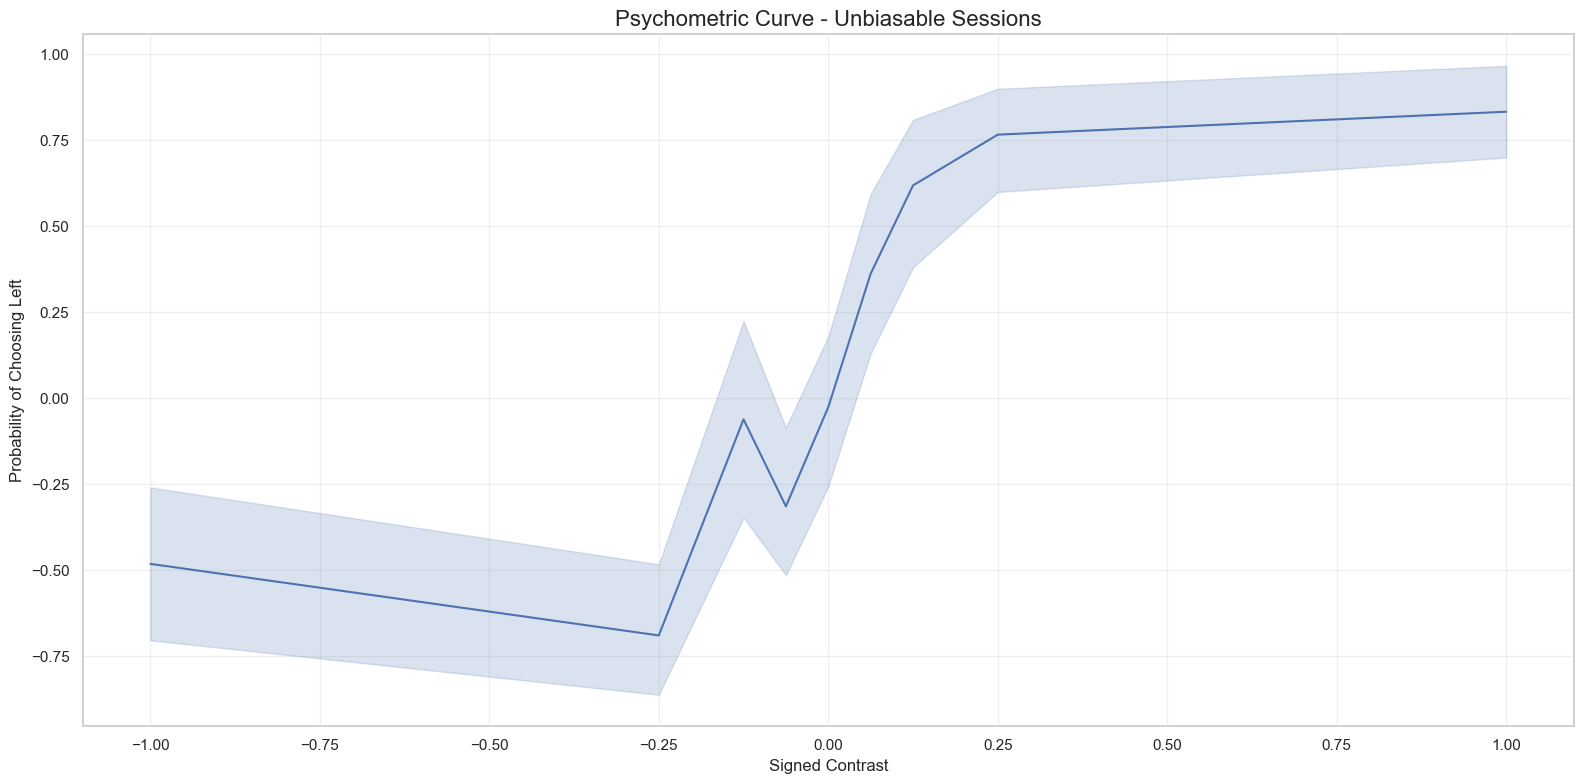

In [ ]:
# plot psychometric curves for unbiasable sessions
# 
# Filter only 'unbiasable' sessions
unbiasable_trials = all_trials[all_trials['training_status'] == 'unbiasable'].copy()

# Create the signed_contrast column for the filtered data
unbiasable_trials['signed_contrast'] = np.nan
i = np.isnan(unbiasable_trials['contrastRight'])
unbiasable_trials.loc[i, 'signed_contrast'] = unbiasable_trials.loc[i, 'contrastLeft']
unbiasable_trials.loc[~i, 'signed_contrast'] = -unbiasable_trials.loc[~i, 'contrastRight']

# Create the plot only for 'unbiasable' sessions
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Plot only trials with probabilityLeft == 0.5 (neutral condition)
sns.lineplot(
    data=unbiasable_trials.loc[unbiasable_trials['probabilityLeft'] == 0.5], 
    x='signed_contrast', 
    y='choice', 
    ax=ax
)

# Customize the plot
ax.set_title('Psychometric Curve - Unbiasable Sessions', fontsize=16)
ax.set_xlabel('Signed Contrast', fontsize=12)
ax.set_ylabel('Probability of Choosing Left', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# get subject list with unbiasable sessions

def plot_unbiasable_subject(subject_name):
    # Filter only 'unbiasable' sessions from the specific subject
    subject_unbiasable = all_trials[
        (all_trials['training_status'] == 'unbiasable') & 
        (all_trials['subject'] == subject_name)
    ].copy()
    
    if len(subject_unbiasable) == 0:
        print(f"No 'unbiasable' sessions found for subject {subject_name}")
        return
    
    # Create the signed_contrast column
    subject_unbiasable['signed_contrast'] = np.nan
    i = np.isnan(subject_unbiasable['contrastRight'])
    subject_unbiasable.loc[i, 'signed_contrast'] = subject_unbiasable.loc[i, 'contrastLeft']
    subject_unbiasable.loc[~i, 'signed_contrast'] = -subject_unbiasable.loc[~i, 'contrastRight']
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    # Filter only trials with probabilityLeft == 0.5
    neutral_trials = subject_unbiasable[subject_unbiasable['probabilityLeft'] == 0.5]

    contrast_stats = neutral_trials.groupby('signed_contrast')['choice'].agg(['mean', 'std', 'count']).reset_index()
    contrast_stats['sem'] = contrast_stats['std'] / np.sqrt(contrast_stats['count'])

    # Plot the psychometric curve
    ax.errorbar(
        contrast_stats['signed_contrast'], 
        contrast_stats['mean'], 
        yerr=contrast_stats['sem'],
        marker='o',
        capsize=5,
        capthick=2,
        linewidth=2
    )
    
    # Customize the plot
    ax.set_title(f'Psychometric Curve - {subject_name} (Unbiasable Sessions)', fontsize=16)
    ax.set_xlabel('Signed Contrast', fontsize=12)
    ax.set_ylabel('Probability of Choosing Left', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Show additional information
    print(f"Subject: {subject_name}")
    print(f"Number of trials: {len(neutral_trials)}")
    print(f"Number of sessions: {neutral_trials['session'].nunique()}")
    
    plt.tight_layout()
    plt.show()


# To see which subjects are available:
print("Available subjects with 'unbiasable' sessions:")
unbiasable_subjects = all_trials[all_trials['training_status'] == 'unbiasable']['subject'].unique()
for subject in unbiasable_subjects:
    print(f"  {subject}")

Available subjects with 'unbiasable' sessions:


NameError: name 'all_trials' is not defined

Subject: CSHL_007
Number of trials: 90
Number of sessions: 1


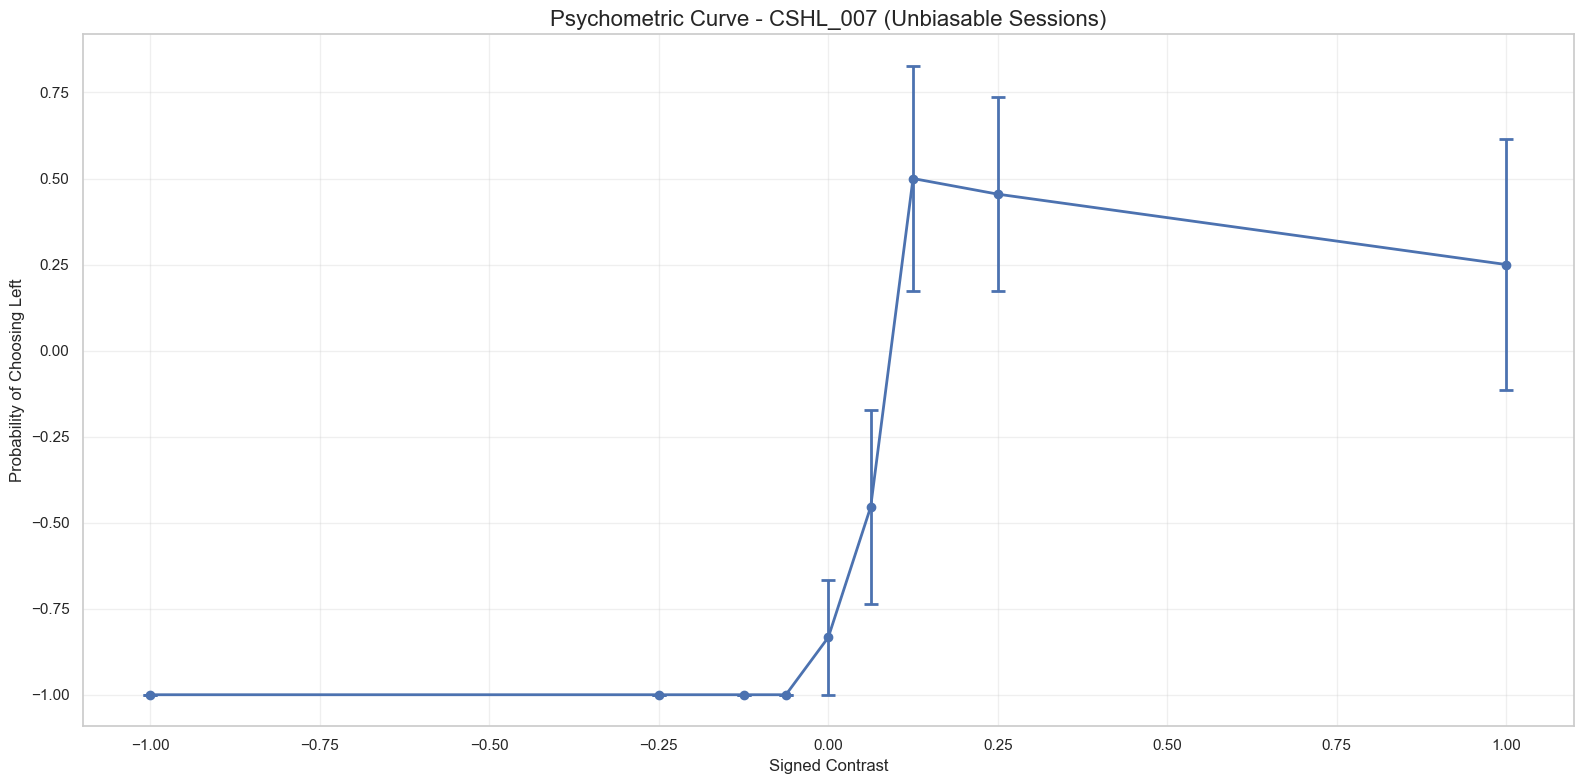

In [ ]:
# plot psychometric curves for a specific subject
plot_unbiasable_subject('CSHL_007')

In [ ]:
# plot psychometric curves for a specific subject

def plot_all_sessions_subject(subject_name, last_n_sessions=None):
    # Filter all sessions for the specific subject
    subject_trials = all_trials[all_trials['subject'] == subject_name].copy()
    
    if len(subject_trials) == 0:
        print(f"No data found for subject {subject_name}")
        return
    
    # Create the signed_contrast column
    subject_trials['signed_contrast'] = np.nan
    i = np.isnan(subject_trials['contrastRight'])
    subject_trials.loc[i, 'signed_contrast'] = subject_trials.loc[i, 'contrastLeft']
    subject_trials.loc[~i, 'signed_contrast'] = -subject_trials.loc[~i, 'contrastRight']
    
    # Filter only trials with probabilityLeft == 0.5
    neutral_trials = subject_trials[subject_trials['probabilityLeft'] == 0.5]
    
    # If last_n_sessions is specified, filter to only those sessions
    if last_n_sessions is not None:
        # Get the last n sessions by training_day
        last_sessions = neutral_trials.groupby('session')['training_day'].first().nlargest(last_n_sessions).index
        neutral_trials = neutral_trials[neutral_trials['session'].isin(last_sessions)]
    
    # Create the graph
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    # Para cada sesión, graficar puntos con media y SEM, y líneas que los conecten
    sessions = neutral_trials['session'].unique()
    colors = sns.color_palette('viridis', n_colors=len(sessions))
    
    for idx, session in enumerate(sessions):
        session_data = neutral_trials[neutral_trials['session'] == session]
        stats = session_data.groupby('signed_contrast')['choice'].agg(['mean', 'std', 'count']).reset_index()
        stats['sem'] = stats['std'] / stats['count']**0.5
        
        # Ordenar por signed_contrast para que las líneas se conecten correctamente
        stats = stats.sort_values('signed_contrast')
        
        # Graficar líneas que conecten los puntos
        ax.plot(
            stats['signed_contrast'], 
            stats['mean'], 
            color=colors[idx],
            alpha=0.7,
            linewidth=2
        )
        
        # Graficar puntos con barras de error
        ax.errorbar(
            stats['signed_contrast'], 
            stats['mean'], 
            yerr=stats['sem'],
            fmt='o', 
            color=colors[idx],
            alpha=0.7,
            capsize=4,
            markersize=6
        )
    
    # Customize the graph
    title = f'Psychometric Curve - {subject_name}'
    if last_n_sessions is not None:
        title += f' (Last {last_n_sessions} Sessions)'
    else:
        title += ' (All Sessions)'
    
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Signed Contrast', fontsize=12)
    ax.set_ylabel('Probability of Choosing Left', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Show additional information
    print(f"Subject: {subject_name}")
    print(f"Number of sessions shown: {len(sessions)}")
    print(f"Total number of trials: {len(neutral_trials)}")
    print(f"Training statuses: {neutral_trials['training_status'].unique()}")
    
    plt.tight_layout()
    plt.show()

Subject: CSHL_007
Number of sessions shown: 10
Total number of trials: 900
Training statuses: [nan]


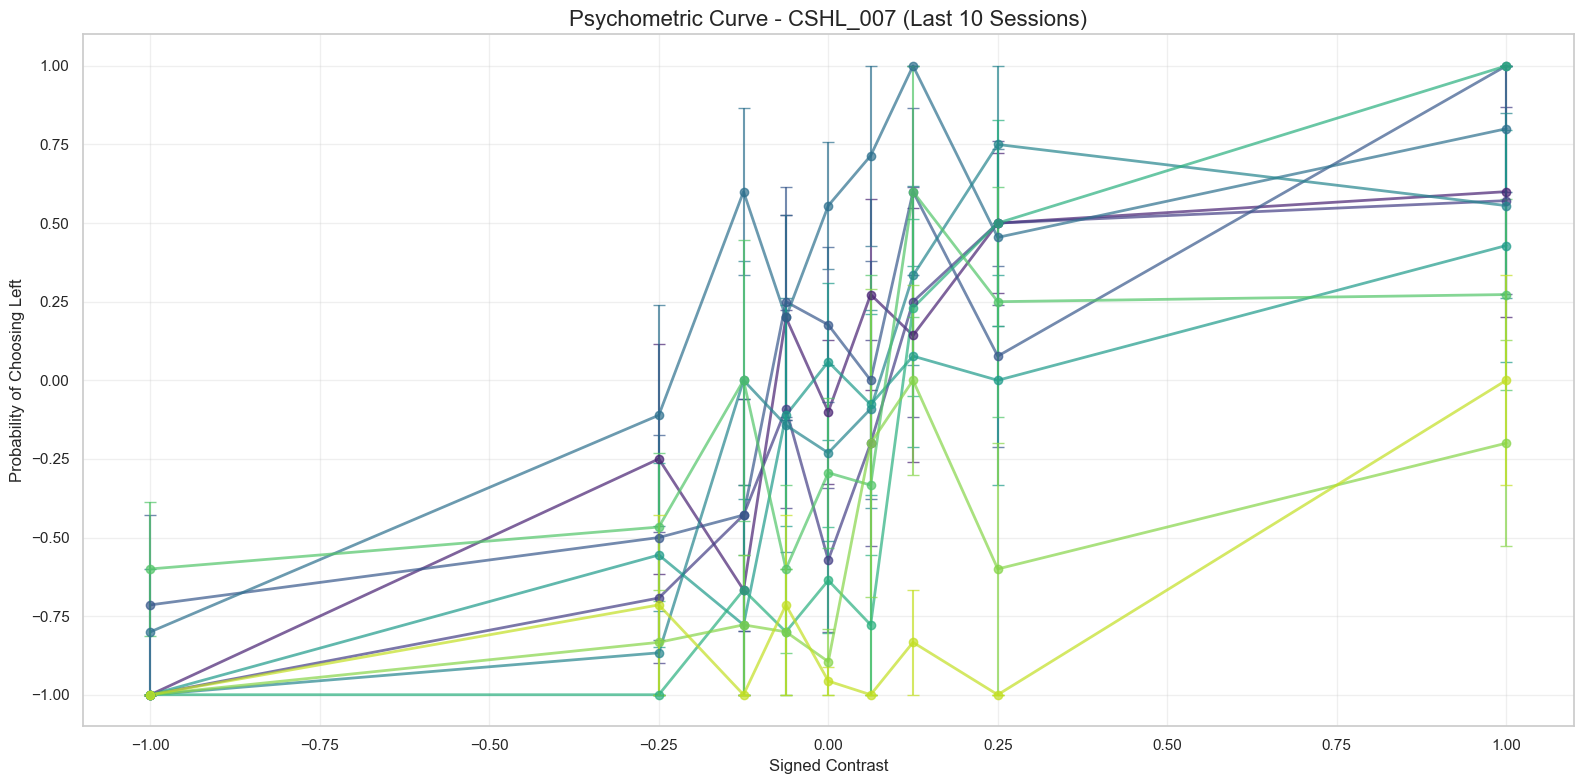

In [ ]:
# plot psychometric curves for a specific subject
plot_all_sessions_subject('CSHL_007', last_n_sessions=10)


In [9]:
import pandas as pd

# Ruta al archivo (usa r'' para evitar problemas con las barras invertidas)
file_path = r"\\QNAP-AL001.dpag.ox.ac.uk\Data\ibl_brain_wide_map\angelakilab\Subjects\NYU-11\2020-02-18\001\alf\_ibl_trials.table.pqt"

# Leer el archivo Parquet
df = pd.read_parquet(file_path)

# Ver las primeras filas del archivo
print(df.head())

# Ver las columnas disponibles
print("\nColumnas en el archivo:")
print(df.columns.tolist())

# Ver el número de filas
print(f"\nNúmero de filas: {len(df)}")

         intervals_0  intervals_1  firstMovement_times  goCue_times  \
trial_#                                                               
0         253.482165   316.145202            312.82632   268.879856   
1         316.681801   379.858404                  NaN   317.357932   
2         380.367104   387.172959            385.42132   381.062242   
3         387.604860   407.160811            404.07032   389.145186   
4         407.631209   470.893152                  NaN   408.392684   

         probabilityLeft  response_times  feedbackType  rewardVolume  \
trial_#                                                                
0                    0.5      313.593986            -1           0.0   
1                    0.5      377.358385            -1           0.0   
2                    0.5      385.593944             1           1.5   
3                    0.5      404.595102            -1           0.0   
4                    0.5      468.393136            -1           0.0  

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import re

def plot_psychometric_curve(trials_df, file_path):
    """
    Plots the psychometric curve for an animal based on trial data.
    The plot title is generated from the file path, using the animal name and session date.
    
    Parameters:
        trials_df (pd.DataFrame): DataFrame containing trial data.
        file_path (str): Path to the parquet file.
    """
    # Extract animal name and session date from the file path
    match = re.search(r"Subjects[\\/](.*?)[\\/](\d{4}-\d{2}-\d{2})", file_path)
    if match:
        animal = match.group(1)
        session_date = match.group(2)
        title = f"Psychometric Curve - {animal} - {session_date}"
    else:
        title = "Psychometric Curve"
    
    # Create a signed contrast column: positive for left, negative for right
    trials_df = trials_df.copy()
    trials_df['signed_contrast'] = np.nan
    i = trials_df['contrastRight'].isna()
    trials_df.loc[i, 'signed_contrast'] = trials_df.loc[i, 'contrastLeft']
    trials_df.loc[~i, 'signed_contrast'] = -trials_df.loc[~i, 'contrastRight']
    
    # Only keep trials with a valid choice (-1: right, 1: left)
    valid_choices = trials_df['choice'].isin([-1, 1])
    data = trials_df[valid_choices].copy()
    
    # Convert choices: 1 (left) -> 1, -1 (right) -> 0
    data['choice_left'] = (data['choice'] == 1).astype(int)
    
    # Group by signed contrast and calculate mean and SEM of choosing left
    stats = data.groupby('signed_contrast')['choice_left'].agg(['mean', 'count', 'std']).reset_index()
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.errorbar(stats['signed_contrast'], stats['mean'], yerr=stats['sem'], fmt='o-', capsize=4)
    plt.xlabel('Signed Contrast (Left +, Right -)')
    plt.ylabel('Probability of Choosing Left')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

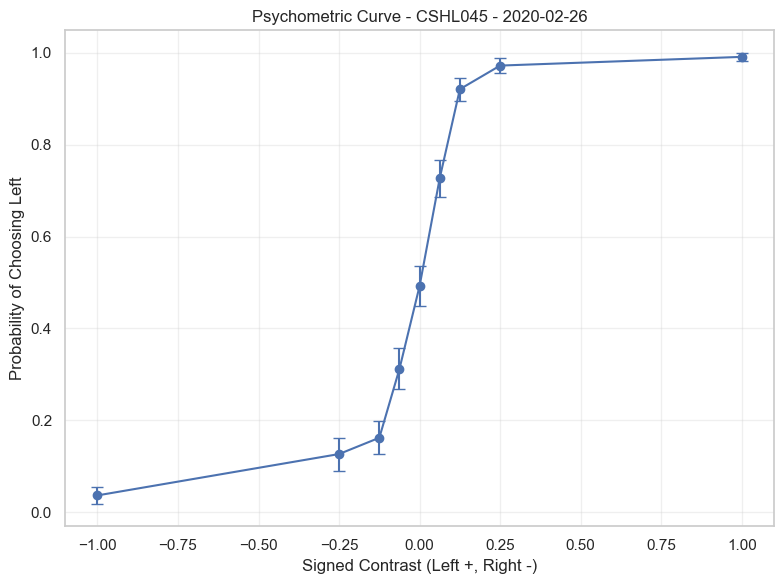

In [20]:
file_path = r"\\QNAP-AL001.dpag.ox.ac.uk\Data\ibl_brain_wide_map\churchlandlab\Subjects\CSHL045\2020-02-26\001\alf\_ibl_trials.table.pqt"
df = pd.read_parquet(file_path)
plot_psychometric_curve(df, file_path)

In [15]:
df

,contrastRight,rewardVolume,choice,intervals_0,intervals_1,feedbackType,response_times,stimOn_times,firstMovement_times,feedback_times,probabilityLeft,contrastLeft,goCue_times
trial_#,,,,,,,,,,,,,
0,NaN,1.5,1,24.255300,27.155932,1,25.593314,24.955967,25.085,25.593400,0.5,1.0000,24.956833
1,0.1250,1.5,-1,27.529633,36.087999,1,34.529686,33.937967,34.067,34.529800,0.5,NaN,33.939100
2,NaN,1.5,1,36.475300,39.887832,1,38.307416,37.522133,37.476,38.307533,0.5,0.1250,37.523100
3,NaN,1.5,1,40.259933,44.721166,1,43.122853,42.655667,42.779,43.122967,0.5,1.0000,42.656733
4,NaN,1.5,1,45.125267,49.888830,1,48.298108,47.705600,47.852,48.298200,0.5,0.2500,47.706367
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1014,0.0625,1.5,-1,5411.642400,5416.688355,1,5415.099537,5412.220167,5412.354,5415.099633,0.8,NaN,5412.221233
1015,NaN,1.5,1,5417.931567,5423.187823,1,5421.604804,5418.703600,5418.893,5421.604900,0.8,0.1250,5418.704533
1016,NaN,1.5,1,5424.435233,5427.170258,1,5425.583343,5425.186767,5425.246,5425.583433,0.8,0.1250,5425.187867


In [3]:
# plot psychometric curves for all sessions of all animals of all labs in the local IBL dataset

import os
import pandas as pd
import traceback

def plot_psychometric_curve_and_save(trials_df, file_path, save_path):
    import matplotlib.pyplot as plt
    import numpy as np
    import re

    # Extract lab, animal, session date, and session number from the file path
    match = re.search(r"([A-Za-z0-9_-]+)[\\/](Subjects)[\\/](.*?)[\\/](\d{4}-\d{2}-\d{2})[\\/](\d+)", file_path)
    if match:
        lab = match.group(1)
        animal = match.group(3)
        session_date = match.group(4)
        session_num = match.group(5)
        title = f"Psychometric Curve - {animal} - {session_date} - {session_num}"
    else:
        title = "Psychometric Curve"
    
    trials_df = trials_df.copy()
    trials_df['signed_contrast'] = np.nan
    i = trials_df['contrastRight'].isna()
    # Invertir la lógica: cuando contrastLeft está presente, es negativo (izquierda)
    trials_df.loc[i, 'signed_contrast'] = -trials_df.loc[i, 'contrastLeft']
    # Cuando contrastRight está presente, es positivo (derecha)
    trials_df.loc[~i, 'signed_contrast'] = trials_df.loc[~i, 'contrastRight']
    
    valid_choices = trials_df['choice'].isin([-1, 1])
    data = trials_df[valid_choices].copy()
    data['choice_right'] = (data['choice'] == -1).astype(int)
    
    stats = data.groupby('signed_contrast')['choice_right'].agg(['mean', 'count', 'std']).reset_index()
    stats['sem'] = stats['std'] / np.sqrt(stats['count'])
    
    plt.figure(figsize=(8, 6))
    plt.errorbar(stats['signed_contrast'], stats['mean'], yerr=stats['sem'], fmt='o-', capsize=4)
    plt.xlabel('Signed Contrast (Left -, Right +)')
    plt.ylabel('Probability of Choosing Right')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    # Add horizontal dashed line at y=0.5
    plt.axhline(y=0.5, color='grey', linestyle='--', linewidth=1)
    # Add vertical dashed line at x=0
    plt.axvline(x=0, color='grey', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.close()

def process_all_sessions(root_path):
    """
    Loops through all labs, animals, dates, and sessions, runs the psychometric curve function,
    and saves the plots in a 'behaviour' folder in the current working directory.
    Now considers the 'Subjects' subfolder after each lab.
    """
    behaviour_dir = os.path.join(os.getcwd(), 'behaviour')
    os.makedirs(behaviour_dir, exist_ok=True)
    total_files = 0
    saved_files = 0
    for lab in os.listdir(root_path):
        lab_path = os.path.join(root_path, lab)
        if not os.path.isdir(lab_path):
            continue
        subjects_path = os.path.join(lab_path, 'Subjects')
        if not os.path.isdir(subjects_path):
            continue
        for animal in os.listdir(subjects_path):
            animal_path = os.path.join(subjects_path, animal)
            if not os.path.isdir(animal_path):
                continue
            for date in os.listdir(animal_path):
                date_path = os.path.join(animal_path, date)
                if not os.path.isdir(date_path):
                    continue
                for session in os.listdir(date_path):
                    session_path = os.path.join(date_path, session, 'alf')
                    if not os.path.isdir(session_path):
                        continue
                    file_path = os.path.join(session_path, '_ibl_trials.table.pqt')
                    if os.path.exists(file_path):
                        print(f"Found file: {file_path}")
                        total_files += 1
                        try:
                            df = pd.read_parquet(file_path)
                            print(f"  DataFrame shape: {df.shape}")
                            if df.empty:
                                print("  WARNING: DataFrame is empty, skipping.")
                                continue
                            plot_title = f"{lab}_{animal}_{date}_{session}.png"
                            save_path = os.path.join(behaviour_dir, plot_title)
                            print(f"  Saving plot to: {save_path}")
                            plot_psychometric_curve_and_save(df, file_path, save_path)
                            print(f"  Saved: {save_path}")
                            saved_files += 1
                        except Exception as e:
                            print(f"  Error processing {file_path}: {e}")
                            traceback.print_exc()
    print(f"\nTotal files found: {total_files}")
    print(f"Total plots saved: {saved_files}")

# Example usage:
root_path = r"\\QNAP-AL001.dpag.ox.ac.uk\Data\ibl_brain_wide_map"
process_all_sessions(root_path)

Found file: \\QNAP-AL001.dpag.ox.ac.uk\Data\ibl_brain_wide_map\steinmetzlab\Subjects\NR_0017\2022-03-22\001\alf\_ibl_trials.table.pqt
  DataFrame shape: (911, 13)
  Saving plot to: c:\Users\Lak Lab\Downloads\IBL dataset\behaviour\steinmetzlab_NR_0017_2022-03-22_001.png
  Saved: c:\Users\Lak Lab\Downloads\IBL dataset\behaviour\steinmetzlab_NR_0017_2022-03-22_001.png
Found file: \\QNAP-AL001.dpag.ox.ac.uk\Data\ibl_brain_wide_map\steinmetzlab\Subjects\NR_0019\2022-04-29\001\alf\_ibl_trials.table.pqt
  DataFrame shape: (581, 13)
  Saving plot to: c:\Users\Lak Lab\Downloads\IBL dataset\behaviour\steinmetzlab_NR_0019_2022-04-29_001.png
  Saved: c:\Users\Lak Lab\Downloads\IBL dataset\behaviour\steinmetzlab_NR_0019_2022-04-29_001.png
Found file: \\QNAP-AL001.dpag.ox.ac.uk\Data\ibl_brain_wide_map\steinmetzlab\Subjects\NR_0019\2022-05-01\001\alf\_ibl_trials.table.pqt
  DataFrame shape: (478, 13)
  Saving plot to: c:\Users\Lak Lab\Downloads\IBL dataset\behaviour\steinmetzlab_NR_0019_2022-05-01_00

response times

In [ ]:
def plot_response_times_brain_area(one, brain_area, tag=None):
    """
    Calculates and plots the mean response times for trials where there was insertion in the specified brain area.
    
    Parameters:
    -----------
    one : ONE object
        IBL ONE object for data access
    brain_area : str
        Brain area acronym (e.g., 'ACAd', 'CLA', 'PF', etc.)
    tag : str, optional
        Tag to filter sessions
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Get all insertions in the specified brain area
    insertions = one.search_insertions(atlas_acronym=brain_area, tag=tag)
    
    if len(insertions) == 0:
        print(f"No insertions found in {brain_area}")
        return
    
    print(f"Found {len(insertions)} insertions in {brain_area}")
    
    # Store response times for each session
    session_response_times = []
    session_ids = []
    
    for i, insertion in enumerate(insertions):
        try:
            pid = insertion
            eid, _ = one.pid2eid(pid)
            
            # Load trials data
            trials = one.load_object(eid, 'trials')
            
            # Get response times for trials where animal responded
            valid_response_mask = ~np.isnan(trials['response_times'])
            response_times = trials['response_times'][valid_response_mask]
            
            if len(response_times) > 0:
                session_response_times.append(response_times)
                session_ids.append(f"Session {i+1}")
                print(f"Session {i+1}: {len(response_times)} valid trials, mean RT: {np.mean(response_times):.3f}s")
            else:
                print(f"Session {i+1}: No valid response times")
                
        except Exception as e:
            print(f"Error in session {i+1}: {e}")
            continue
    
    if not session_response_times:
        print("No valid response times found")
        return
    
    # Create the plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot 1: Mean response time per session
    mean_rts = [np.mean(rt) for rt in session_response_times]
    sem_rts = [np.std(rt) / np.sqrt(len(rt)) for rt in session_response_times]
    
    x_pos = np.arange(len(session_ids))
    bars = ax1.bar(x_pos, mean_rts, yerr=sem_rts, capsize=5, alpha=0.7, color='skyblue')
    ax1.set_xlabel('Session')
    ax1.set_ylabel('Mean Response Time (s)')
    ax1.set_title(f'Mean Response Times by Session ({brain_area})')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(session_ids, rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, mean_rt) in enumerate(zip(bars, mean_rts)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{mean_rt:.3f}', ha='center', va='bottom', fontsize=8)
    
    # Plot 2: Distribution of all response times
    all_response_times = np.concatenate(session_response_times)
    ax2.hist(all_response_times, bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
    ax2.axvline(np.mean(all_response_times), color='red', linestyle='--', 
                label=f'Mean: {np.mean(all_response_times):.3f}s')
    ax2.set_xlabel('Response Time (s)')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'Distribution of All Response Times ({brain_area})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics for {brain_area}:")
    print(f"Total sessions analyzed: {len(session_response_times)}")
    print(f"Total trials: {len(all_response_times)}")
    print(f"Overall mean response time: {np.mean(all_response_times):.3f} ± {np.std(all_response_times):.3f}s")
    print(f"Overall median response time: {np.median(all_response_times):.3f}s")
    
    return session_response_times, session_ids

In [ ]:
response_times_data, session_names = plot_response_times_brain_area(one, 'ACAd', tag=tag)

In [ ]:
def plot_response_times_by_contrast(one, brain_area, tag=None):
    """
    Plots response times for each contrast level separated by left/right side across all sessions of the specified brain area.
    
    Parameters:
    -----------
    one : ONE object
        IBL ONE object for data access
    brain_area : str
        Brain area acronym (e.g., 'ACAd', 'CLA', 'PF', etc.)
    tag : str, optional
        Tag to filter sessions
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import pandas as pd
    
    # Set style for better aesthetics
    plt.style.use('default')
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.linewidth'] = 1.5
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.spines.right'] = False
    
    # Get all insertions in the specified brain area
    insertions = one.search_insertions(atlas_acronym=brain_area, tag=tag)
    
    if len(insertions) == 0:
        print(f"No insertions found in {brain_area}")
        return
    
    print(f"Found {len(insertions)} insertions in {brain_area}")
    print(f"Analyzing all sessions...")
    
    # Store all response times for each contrast and side across all sessions
    all_left_data = {}
    all_right_data = {}
    
    for session_idx, insertion in enumerate(insertions):
        try:
            pid = insertion
            eid, _ = one.pid2eid(pid)
            
            # Load trials data
            trials = one.load_object(eid, 'trials')
            
            # Get valid trials (where animal responded)
            valid_response_mask = ~np.isnan(trials['response_times'])
            
            # Create a DataFrame for easier analysis
            df = pd.DataFrame({
                'response_times': trials['response_times'][valid_response_mask],
                'contrastLeft': trials['contrastLeft'][valid_response_mask],
                'contrastRight': trials['contrastRight'][valid_response_mask],
                'feedbackType': trials['feedbackType'][valid_response_mask]
            })
            
            # Process left contrasts
            left_contrasts = df['contrastLeft'].dropna().unique()
            for contrast in left_contrasts:
                mask = df['contrastLeft'] == contrast
                rts = df.loc[mask, 'response_times'].values
                if len(rts) > 0:
                    if contrast not in all_left_data:
                        all_left_data[contrast] = []
                    all_left_data[contrast].extend(rts)
            
            # Process right contrasts
            right_contrasts = df['contrastRight'].dropna().unique()
            for contrast in right_contrasts:
                mask = df['contrastRight'] == contrast
                rts = df.loc[mask, 'response_times'].values
                if len(rts) > 0:
                    if contrast not in all_right_data:
                        all_right_data[contrast] = []
                    all_right_data[contrast].extend(rts)
            
            print(f"Session {session_idx+1}: Processed {len(df)} trials")
                
        except Exception as e:
            print(f"Error in session {session_idx+1}: {e}")
            continue
    
    if not all_left_data and not all_right_data:
        print("No valid response times found for any contrast")
        return
    
    # Calculate means and SEMs
    left_contrasts_list = sorted(all_left_data.keys())
    right_contrasts_list = sorted(all_right_data.keys())
    
    # Convert left contrasts to negative values for plotting
    left_contrasts_plot = [-c for c in left_contrasts_list]
    
    left_means = [np.mean(all_left_data[c]) for c in left_contrasts_list]
    left_sems = [np.std(all_left_data[c]) / np.sqrt(len(all_left_data[c])) for c in left_contrasts_list]
    left_counts = [len(all_left_data[c]) for c in left_contrasts_list]
    
    right_means = [np.mean(all_right_data[c]) for c in right_contrasts_list]
    right_sems = [np.std(all_right_data[c]) / np.sqrt(len(all_right_data[c])) for c in right_contrasts_list]
    right_counts = [len(all_right_data[c]) for c in right_contrasts_list]
    
    # Create the plot with improved aesthetics
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    # Define colors and markers - all black
    plot_color = 'black'
    marker_size = 10
    line_width = 3
    cap_size = 6
    cap_thick = 2
    
    # Plot left contrasts (negative values)
    if all_left_data:
        ax.errorbar(left_contrasts_plot, left_means, yerr=left_sems, 
                   marker='o', markersize=marker_size, linewidth=line_width, 
                   capsize=cap_size, capthick=cap_thick, elinewidth=2,
                   color=plot_color, label='Left', alpha=0.9, 
                   markerfacecolor=plot_color, markeredgecolor='white', markeredgewidth=2)
        
        # Add trial counts as text
        for i, contrast in enumerate(left_contrasts_plot):
            ax.annotate(f'n={left_counts[i]}', 
                       xy=(contrast, left_means[i]), 
                       xytext=(0, 15), textcoords='offset points',
                       ha='center', va='bottom', fontsize=10, color=plot_color,
                       weight='bold')
    
    # Plot right contrasts (positive values)
    if all_right_data:
        ax.errorbar(right_contrasts_list, right_means, yerr=right_sems, 
                   marker='s', markersize=marker_size, linewidth=line_width, 
                   capsize=cap_size, capthick=cap_thick, elinewidth=2,
                   color=plot_color, label='Right', alpha=0.9,
                   markerfacecolor=plot_color, markeredgecolor='white', markeredgewidth=2)
        
        # Add trial counts as text
        for i, contrast in enumerate(right_contrasts_list):
            ax.annotate(f'n={right_counts[i]}', 
                       xy=(contrast, right_means[i]), 
                       xytext=(0, -20), textcoords='offset points',
                       ha='center', va='top', fontsize=10, color=plot_color,
                       weight='bold')
    
    # Improve axis labels and title
    ax.set_xlabel('Contrast Level (Left: negative, Right: positive)', fontsize=14, weight='bold')
    ax.set_ylabel('Mean Response Time (seconds)', fontsize=14, weight='bold')
    ax.set_title(f'Response Times by Contrast and Side - {brain_area}\n(All Sessions Combined)', 
                 fontsize=16, weight='bold', pad=20)
    
    # Improve legend
    ax.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, 
             loc='upper right', framealpha=0.9)
    
    # Improve grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
    
    # Set x-axis limits with padding and add vertical line at x=0
    all_contrasts_plot = np.concatenate([left_contrasts_plot, right_contrasts_list])
    if len(all_contrasts_plot) > 0:
        ax.set_xlim(min(all_contrasts_plot) - 0.05, max(all_contrasts_plot) + 0.05)
        # Add vertical line at x=0 to separate left and right
        ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5, linewidth=1)
    
    # Improve tick labels
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5, length=6)
    
    # Add some padding around the plot
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nSummary Statistics for {brain_area} (All Sessions Combined):")
    total_trials = sum(left_counts) + sum(right_counts)
    print(f"Total trials analyzed: {total_trials}")
    
    if all_left_data:
        print(f"\nLeft side ({len(all_left_data)} contrast levels):")
        for i, contrast in enumerate(left_contrasts_list):
            print(f"  Contrast {contrast:.2f}: {left_counts[i]} trials, "
                  f"mean: {left_means[i]:.3f} ± {left_sems[i]:.3f}s")
    
    if all_right_data:
        print(f"\nRight side ({len(all_right_data)} contrast levels):")
        for i, contrast in enumerate(right_contrasts_list):
            print(f"  Contrast {contrast:.2f}: {right_counts[i]} trials, "
                  f"mean: {right_means[i]:.3f} ± {right_sems[i]:.3f}s")
    
    return all_left_data, all_right_data, left_contrasts_list, right_contrasts_list

In [ ]:
contrast_data, contrasts = plot_response_times_by_contrast(one, 'ACAd', tag=tag)